# 🌧️ Monthly Rainfall EDA — India (1901–2023)
### Extreme Pattern Discovery using Matplotlib & Seaborn

**Dataset:** 44,280 records · 12 features · 123 years · Monthly district-level rainfall across India

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CHARTS = 'charts/'
import os; os.makedirs(CHARTS, exist_ok=True)

df = pd.read_csv('02_monthly_rainfall_district_1901_2023.csv')
df['decade']       = (df['year'] // 10) * 10
decade_labels      = {1900:'1900s',1910:'1910s',1920:'1920s',1930:'1930s',
                      1940:'1940s',1950:'1950s',1960:'1960s',1970:'1970s',
                      1980:'1980s',1990:'1990s',2000:'2000s',2010:'2010s',2020:'2020s'}
df['decade_label'] = df['decade'].map(decade_labels)

months_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cat_colors   = {'Excess':'#0984e3','Normal':'#00b894','Deficient':'#e17055','Scanty':'#636e72'}

print(f"Total records   : {len(df):,}")
print(f"  Year range    : {df['year'].min()} – {df['year'].max()}")
print(f"  States        : {df['state'].nunique()}")
print(f"  Districts     : {df['district'].nunique()}")
print(f"  Agro zones    : {df['agro_zone'].nunique()}")
df.head()

Total records   : 44,280
  Year range    : 1901 – 2023
  States        : 30
  Districts     : 30
  Agro zones    : 4


,year,month,month_num,state,district,agro_zone,rainfall_mm,normal_mm,departure_mm,departure_pct,category,rainy_days_est,decade,decade_label
0,1901,Jan,1,Andhra Pradesh,Andhra Pradesh Central,Semi-Arid,45.1,23.6,21.5,90.9,Excess,5,1900,1900s
1,1901,Feb,2,Andhra Pradesh,Andhra Pradesh Central,Semi-Arid,32.6,23.6,8.9,37.8,Excess,4,1900,1900s
2,1901,Mar,3,Andhra Pradesh,Andhra Pradesh Central,Semi-Arid,84.8,47.2,37.5,79.4,Excess,10,1900,1900s
3,1901,Apr,4,Andhra Pradesh,Andhra Pradesh Central,Semi-Arid,69.2,70.9,-1.7,-2.3,Normal,8,1900,1900s
4,1901,May,5,Andhra Pradesh,Andhra Pradesh Central,Semi-Arid,175.4,118.1,57.3,48.5,Excess,21,1900,1900s


---
## 1. Rainfall Category Split (Donut Chart)
Shows the overall proportion of Excess, Normal, Deficient, and Scanty months across the full 123-year record. The hollow centre displays total record count — an instant baseline before deeper analysis.

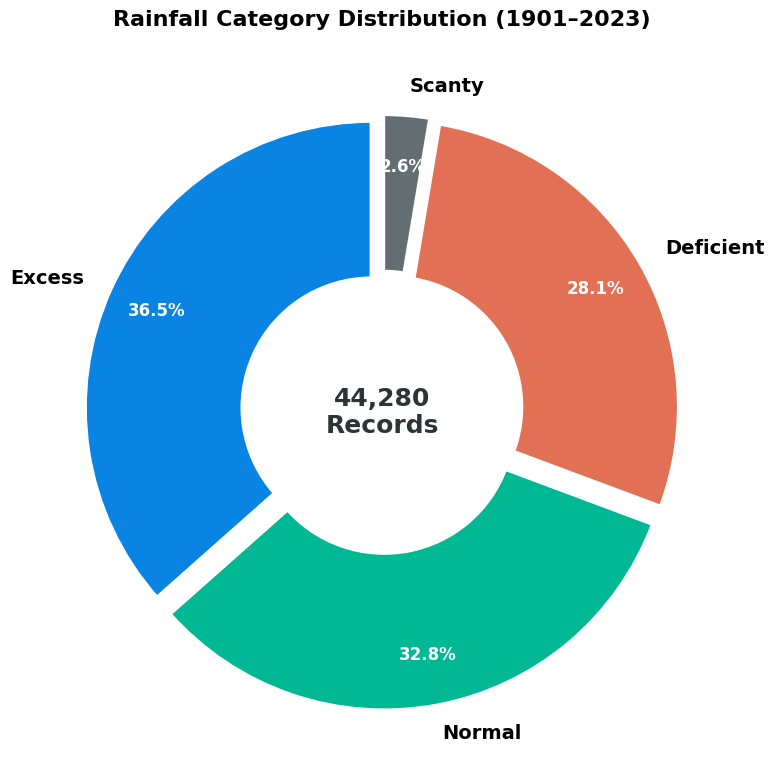

In [4]:
counts = df['category'].value_counts().reindex(['Excess','Normal','Deficient','Scanty'])
colors_d = ['#0984e3','#00b894','#e17055','#636e72']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=colors_d, startangle=90, pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    explode=[0.04, 0.04, 0.04, 0.04])
for t in texts:      t.set_fontsize(14); t.set_fontweight('bold')
for a in autotexts:  a.set_fontsize(12); a.set_color('white'); a.set_fontweight('bold')
ax.text(0, 0, f'{len(df):,}\nRecords', ha='center', va='center',
        fontsize=18, fontweight='bold', color='#2d3436')
ax.set_title('Rainfall Category Distribution (1901–2023)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(CHARTS + '01_category_donut.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Annual Mean Rainfall — Line + Area Chart
Tracks India's district-averaged monthly rainfall year-on-year. Shaded fill encodes cumulative seasonal pressure. Long-term shifts in the trend line are a direct monsoon-variability signal.

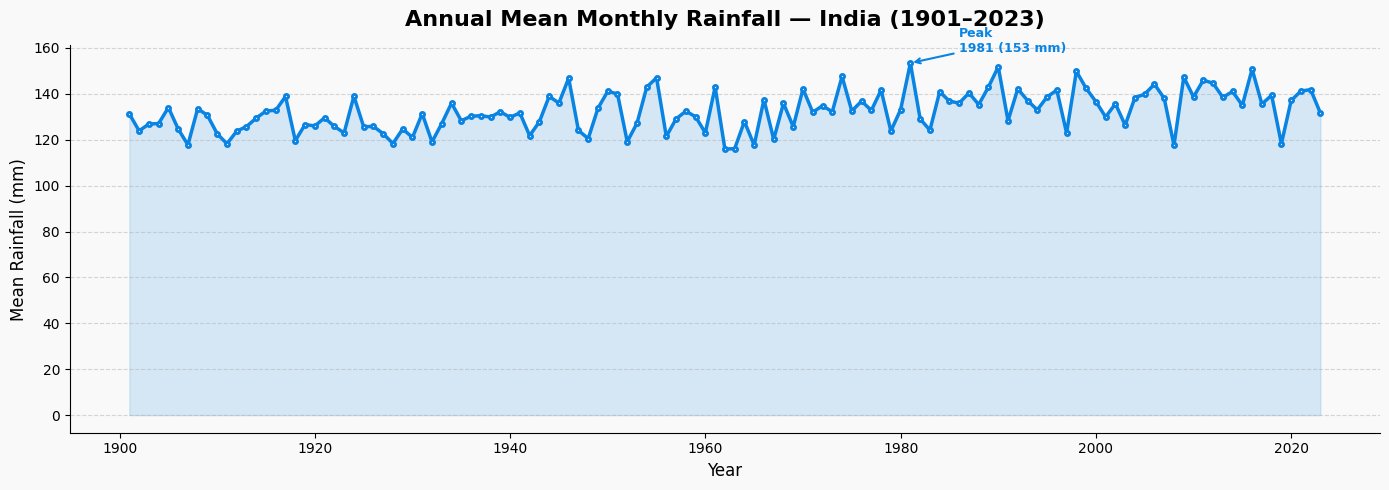

In [5]:
yearly = df.groupby('year')['rainfall_mm'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(yearly['year'], yearly['rainfall_mm'], alpha=0.15, color='#0984e3')
ax.plot(yearly['year'], yearly['rainfall_mm'], color='#0984e3', lw=2.5,
        marker='o', ms=3, markerfacecolor='white', markeredgewidth=2)

peak = yearly.loc[yearly['rainfall_mm'].idxmax()]
ax.annotate(f"Peak\n{int(peak['year'])} ({peak['rainfall_mm']:.0f} mm)",
            xy=(peak['year'], peak['rainfall_mm']),
            xytext=(peak['year']+5, peak['rainfall_mm']+5),
            fontsize=9, color='#0984e3', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#0984e3', lw=1.5))

ax.set_title('Annual Mean Monthly Rainfall — India (1901–2023)', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Year', fontsize=12); ax.set_ylabel('Mean Rainfall (mm)', fontsize=12)
ax.set_facecolor('#f9f9f9'); fig.patch.set_facecolor('#f9f9f9')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(CHARTS + '02_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Monthly Seasonality — Polar Bar Chart
Wraps 12 months onto a wheel coloured by intensity. The towering bars at June–September encode India's monsoon dominance in a single visual — months flanking the peak appear as a sharp shoulder.

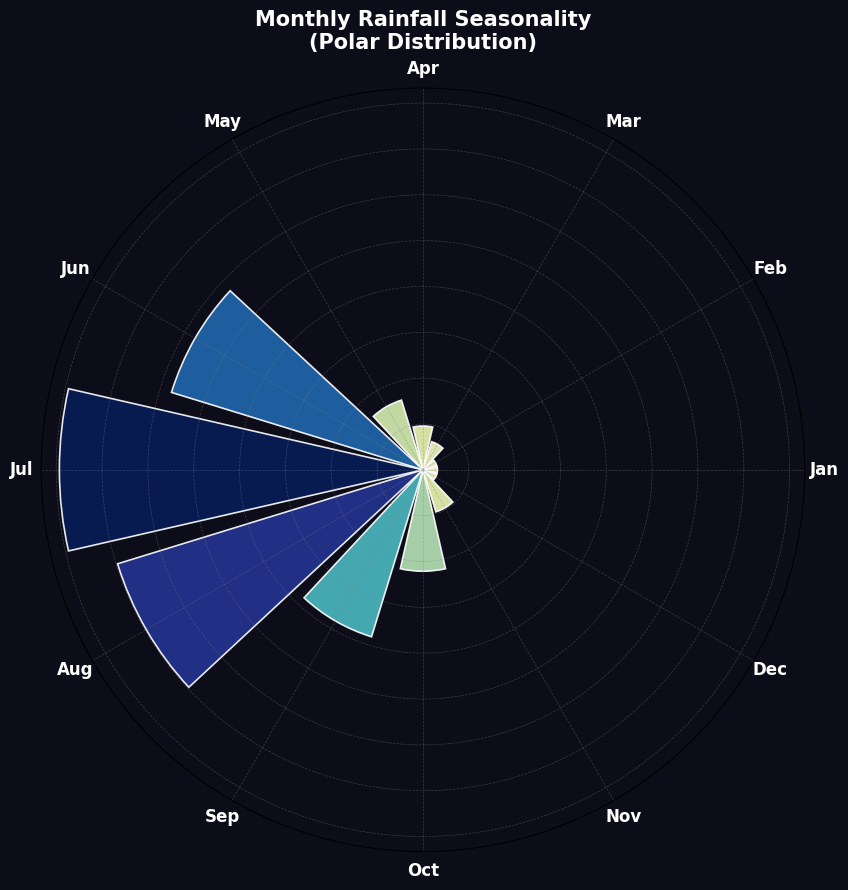

In [6]:
month_avg = df.groupby('month_num')['rainfall_mm'].mean().reindex(range(1,13), fill_value=0)
months_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
values = month_avg.values
colors_p = plt.cm.YlGnBu(values / values.max())

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
bars = ax.bar(angles, values, width=0.45, color=colors_p, edgecolor='white', linewidth=1.2, alpha=0.9)
ax.set_xticks(angles); ax.set_xticklabels(months_labels, fontsize=12, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Monthly Rainfall Seasonality\n(Polar Distribution)', fontsize=15, fontweight='bold', pad=28)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.4)
fig.patch.set_facecolor('#0d0d1a'); ax.set_facecolor('#0d0d1a'); ax.title.set_color('white')
for label in ax.get_xticklabels(): label.set_color('white')
plt.tight_layout()
plt.savefig(CHARTS + '03_monthly_polar.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

---
## 4. Rainfall Distribution by Category — Violin + Strip
Violin width = record density at each rainfall level. White strip dots = individual district-months. Comparing panels reveals how the four IMD category thresholds translate to actual mm distributions — and whether Excess events create a heavy upper tail.

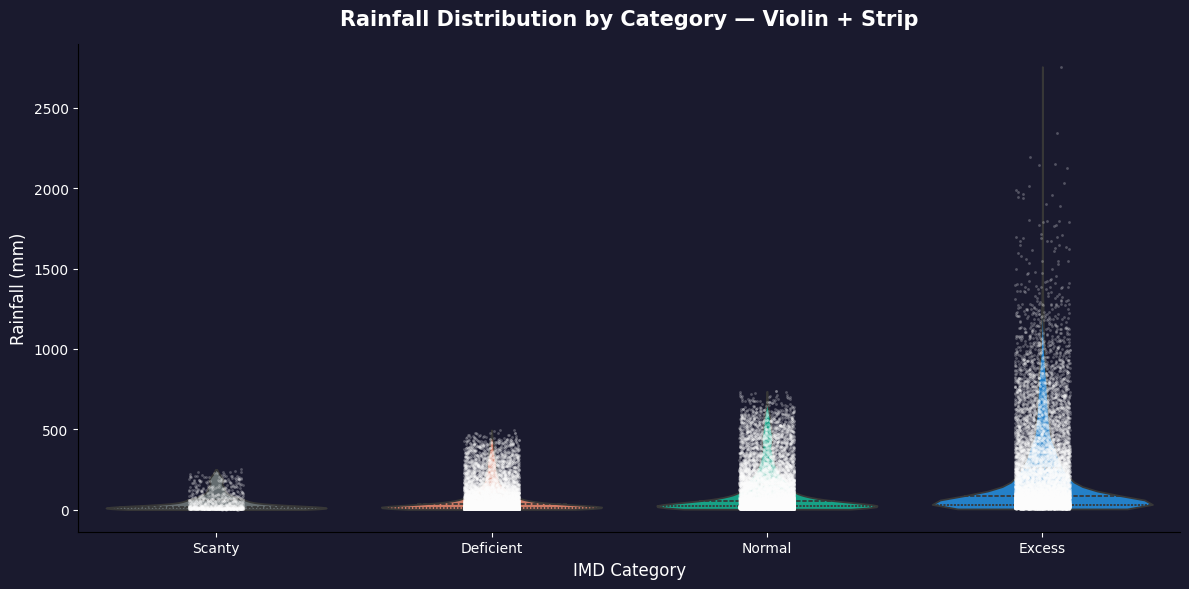

In [7]:
cat_order = ['Scanty','Deficient','Normal','Excess']
palette_v  = ['#636e72','#e17055','#00b894','#0984e3']

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df, x='category', y='rainfall_mm', order=cat_order,
               palette=palette_v, ax=ax, inner='quartile', cut=0)
sns.stripplot(data=df, x='category', y='rainfall_mm', order=cat_order,
              color='white', alpha=0.25, size=2, jitter=True, ax=ax)
ax.set_title('Rainfall Distribution by Category — Violin + Strip', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('IMD Category', fontsize=12); ax.set_ylabel('Rainfall (mm)', fontsize=12)
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#1a1a2e')
ax.title.set_color('white'); ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white'); ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig(CHARTS + '04_category_violin.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

---
## 5. Departure % vs Rainfall — Bubble Scatter
Each point sits at the intersection of percentage departure from normal and actual rainfall (mm). Bubble size = estimated rainy days. Annotated outliers are the most extreme surplus events. The right half (positive departure) = Excess, left = Deficient/Scanty.

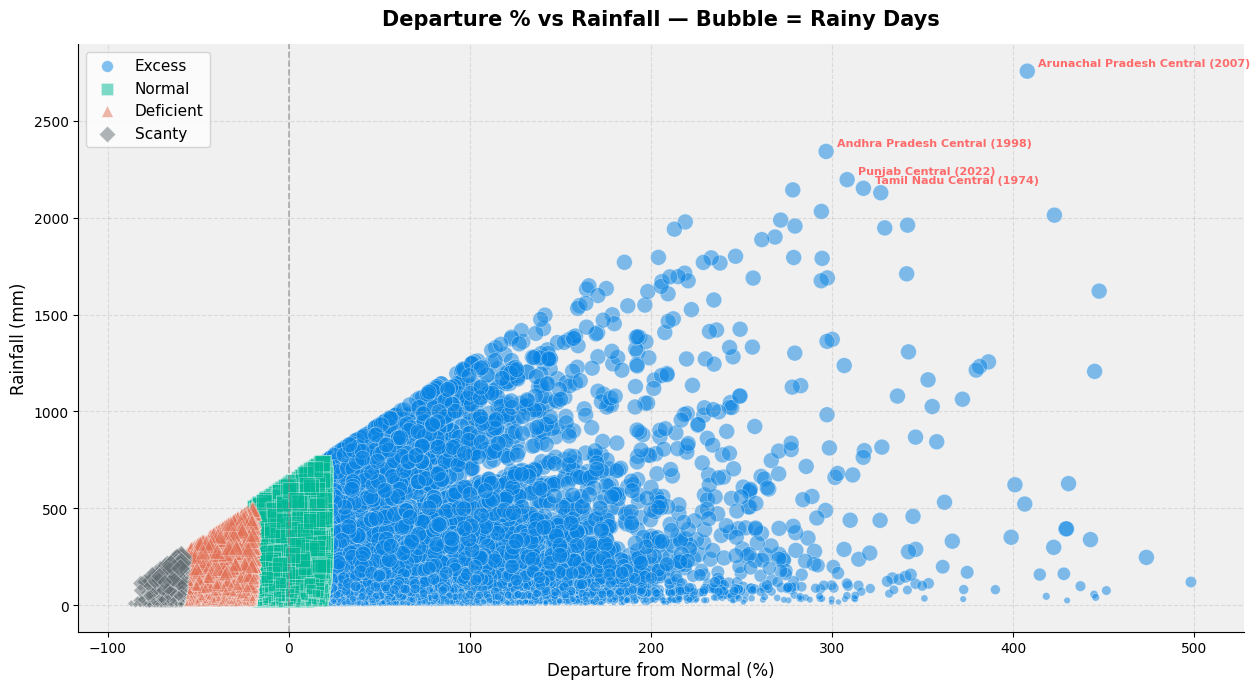

In [8]:
fig, ax = plt.subplots(figsize=(13, 7))
for cat, color, marker in [('Excess','#0984e3','o'),('Normal','#00b894','s'),
                             ('Deficient','#e17055','^'),('Scanty','#636e72','D')]:
    sub = df[df['category']==cat]
    ax.scatter(sub['departure_pct'], sub['rainfall_mm'], c=color, alpha=0.5,
               s=sub['rainy_days_est']*4+10, marker=marker,
               edgecolors='white', linewidths=0.4, label=cat)

top4 = df.nlargest(4, 'rainfall_mm')
for _, r in top4.iterrows():
    ax.annotate(f"{r['district']} ({r['year']})", (r['departure_pct'], r['rainfall_mm']),
                xytext=(8, 4), textcoords='offset points', fontsize=8,
                color='#ff6b6b', fontweight='bold')

ax.axvline(0, color='grey', lw=1.2, linestyle='--', alpha=0.6)
ax.set_title('Departure % vs Rainfall — Bubble = Rainy Days', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Departure from Normal (%)', fontsize=12); ax.set_ylabel('Rainfall (mm)', fontsize=12)
ax.legend(fontsize=11); ax.set_facecolor('#f0f0f0'); ax.grid(linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig(CHARTS + '05_departure_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Year × Month Mean Rainfall Heatmap
Every cell = average district rainfall in that year-month pair. Hot cells expose exactly when monsoon activity clustered — the bright June-to-September band is clearly visible decade after decade, while drought years appear as conspicuously cold rows.

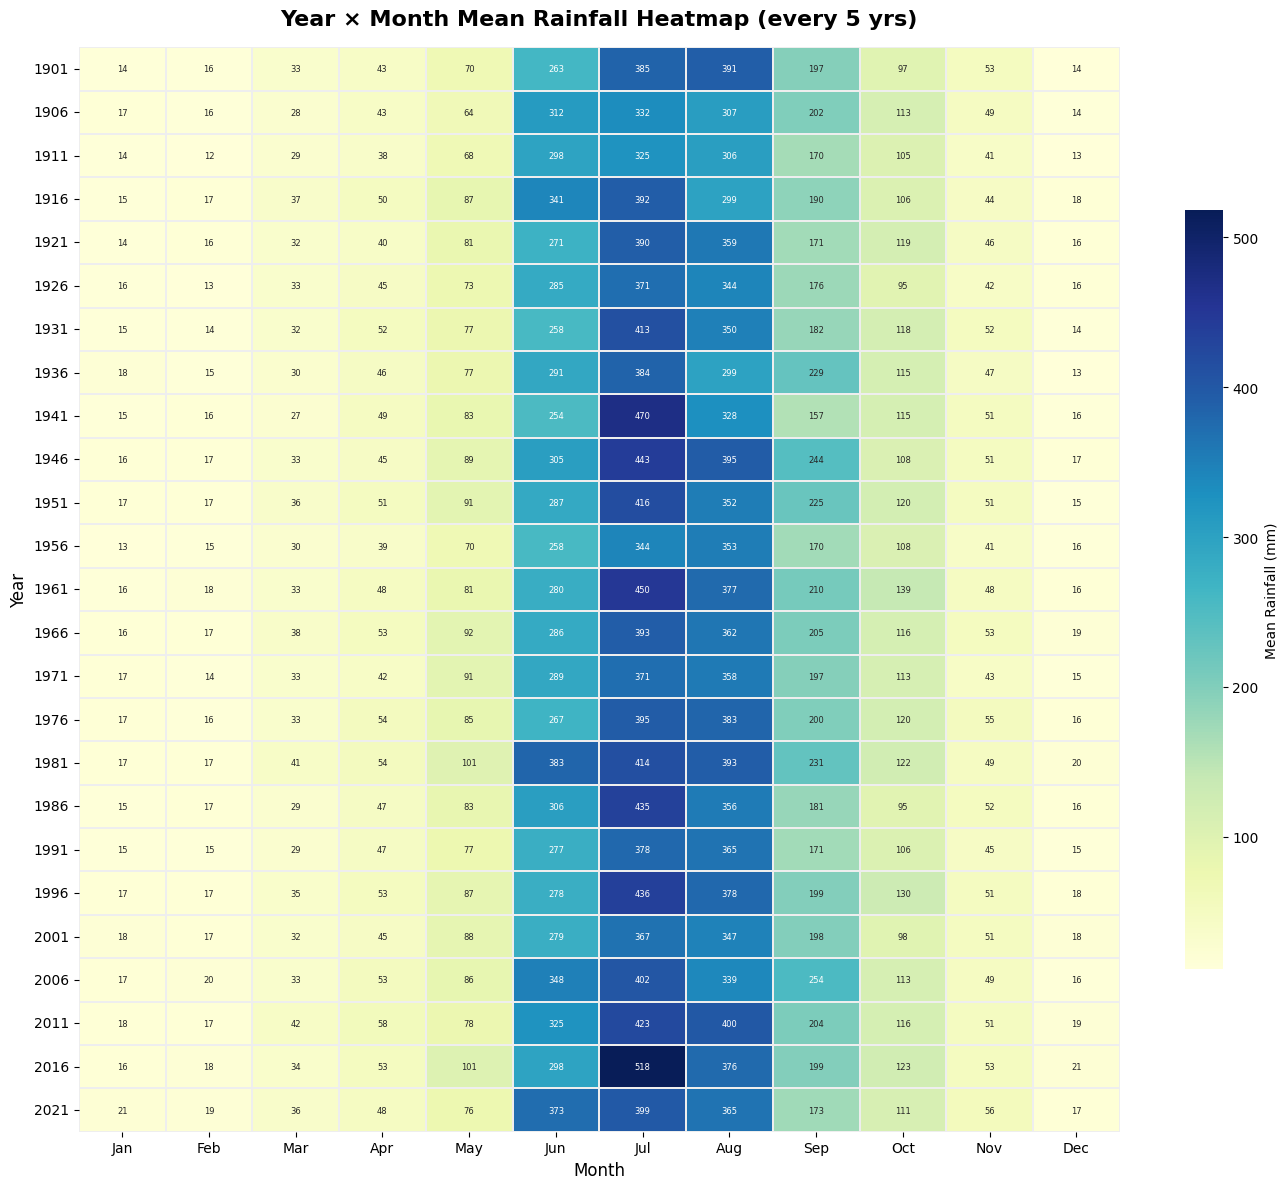

In [9]:
pivot = df.groupby(['year','month_num'])['rainfall_mm'].mean().unstack(fill_value=0)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
# Sample every 5 years for readability
pivot_sample = pivot.iloc[::5]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(pivot_sample, cmap='YlGnBu', linewidths=0.2, linecolor='#eee', ax=ax,
            annot=True, fmt='.0f', cbar_kws={'label':'Mean Rainfall (mm)','shrink':0.7},
            annot_kws={'fontsize': 6})
ax.set_title('Year × Month Mean Rainfall Heatmap (every 5 yrs)', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Month', fontsize=12); ax.set_ylabel('Year', fontsize=12)
ax.tick_params(axis='x', rotation=0); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(CHARTS + '06_heatmap_year_month.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Top 10 Highest Rainfall Records — Horizontal Bar Chart
Blue bars for highest ever district-month rainfall. Annotated with mm value, year, and state. Reveals which districts and seasons have historically broken records — and whether the extremes are concentrated in a few monsoon-belt states.

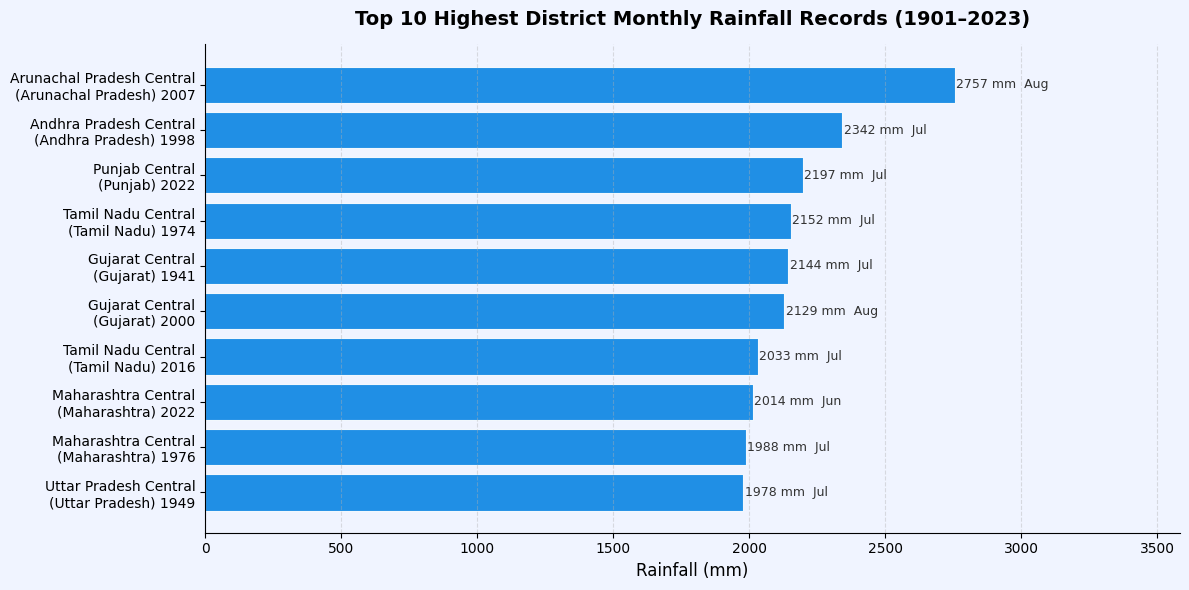

In [10]:
top10 = df.nlargest(10, 'rainfall_mm')[['district','state','rainfall_mm','year','month']].sort_values('rainfall_mm')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['district'] + '\n(' + top10['state'] + ') ' + top10['year'].astype(str),
               top10['rainfall_mm'], color='#0984e3', edgecolor='white', linewidth=0.8, alpha=0.9)
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{row['rainfall_mm']:.0f} mm  {row['month']}",
            va='center', fontsize=9, color='#333')

ax.set_title('Top 10 Highest District Monthly Rainfall Records (1901–2023)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Rainfall (mm)', fontsize=12)
ax.set_xlim(0, top10['rainfall_mm'].max() * 1.3)
ax.set_facecolor('#f0f4ff'); fig.patch.set_facecolor('#f0f4ff')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS + '07_top10_rainfall.png', dpi=150, bbox_inches='tight', facecolor='#f0f4ff')
plt.show()

---
## 8. Top 15 States — Stacked Category Bar
Stacks Excess, Normal, Deficient, and Scanty record counts per state. A state with dominant blue faces chronic flood risk; one with dominant red faces perennial drought. Directly informs state-level water security prioritisation.

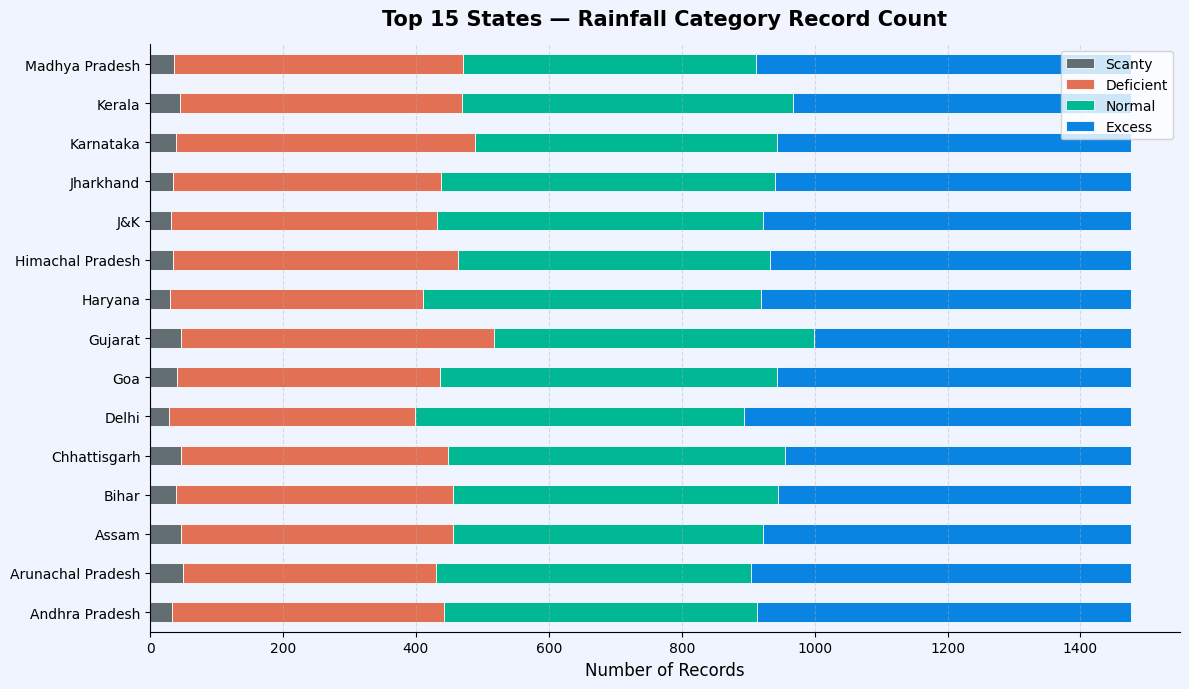

In [11]:
state_counts = df.groupby(['state','category']).size().unstack(fill_value=0)
state_counts['total'] = state_counts.sum(axis=1)
top15 = state_counts.nlargest(15,'total').drop('total', axis=1)
top15 = top15[['Scanty','Deficient','Normal','Excess']]

fig, ax = plt.subplots(figsize=(12, 7))
top15.plot(kind='barh', stacked=True,
           color=['#636e72','#e17055','#00b894','#0984e3'],
           ax=ax, edgecolor='white', linewidth=0.6)
ax.set_title('Top 15 States — Rainfall Category Record Count', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Number of Records', fontsize=12); ax.set_ylabel('')
ax.legend(['Scanty','Deficient','Normal','Excess'], fontsize=10)
ax.set_facecolor('#f0f4ff'); fig.patch.set_facecolor('#f0f4ff')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS + '08_state_stacked.png', dpi=150, bbox_inches='tight', facecolor='#f0f4ff')
plt.show()

---
## 9. Agro-Zone vs Rainfall Category — Cross-tabulation Heatmap
Maps how agro-ecological zones (Arid, Semi-Arid, Sub-Humid, Humid) align with actual rainfall categories. Cells where Arid zones recorded Excess events — or where Humid zones went Scanty — reveal climate stress anomalies beyond the zone's historical baseline.

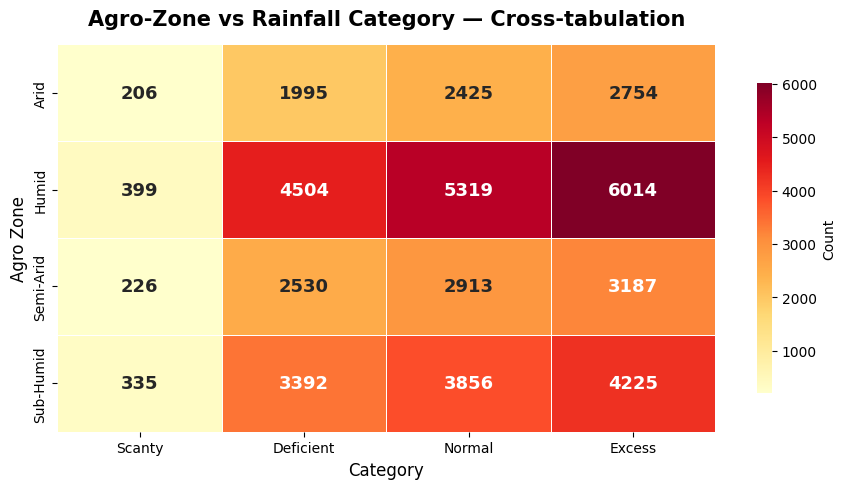

In [12]:
zone_cat = df.groupby(['agro_zone','category']).size().unstack(fill_value=0)
zone_cat = zone_cat[['Scanty','Deficient','Normal','Excess']]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(zone_cat, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5,
            cbar_kws={'label':'Count','shrink':0.8},
            annot_kws={'fontsize':13,'fontweight':'bold'}, ax=ax)
ax.set_title('Agro-Zone vs Rainfall Category — Cross-tabulation', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Category', fontsize=12); ax.set_ylabel('Agro Zone', fontsize=12)
plt.tight_layout()
plt.savefig(CHARTS + '09_agrozone_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Departure % by Month — Grouped Boxplot
Boxes compare how far monthly rainfall deviated from the historical norm for each calendar month. The dashed zero line separates surplus from deficit. Wide boxes at monsoon months indicate high inter-annual variability; tight boxes in winter indicate predictable dryness.

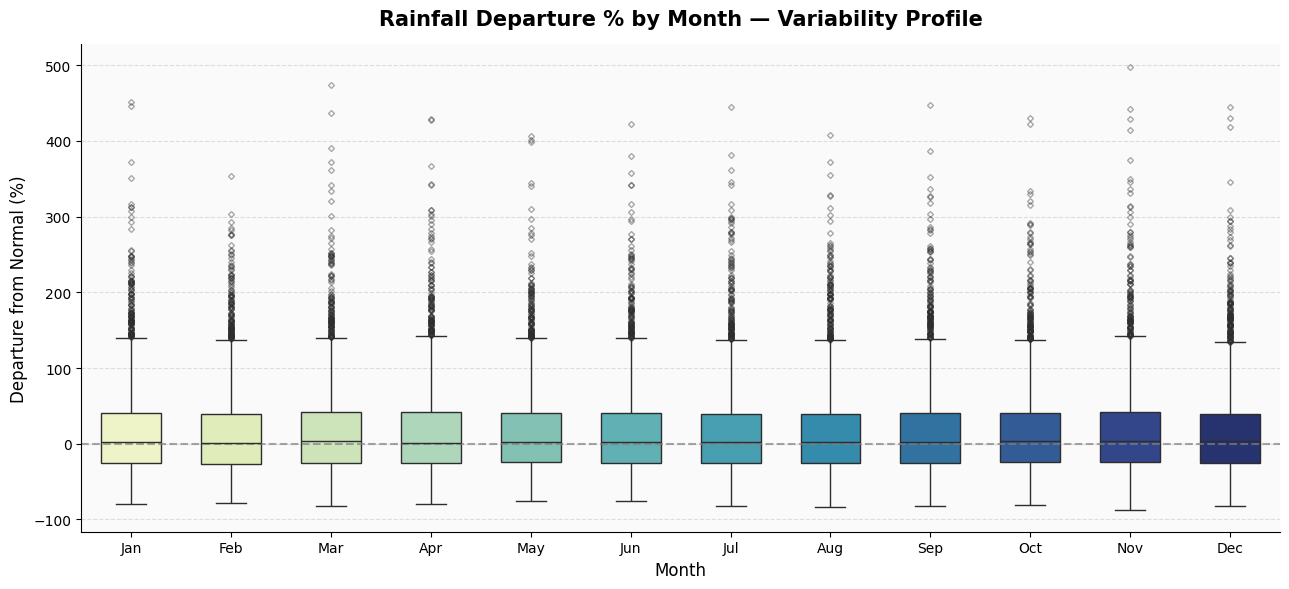

In [13]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=df, x='month', y='departure_pct', order=months_order,
            palette=sns.color_palette('YlGnBu', 12),
            flierprops=dict(marker='D', markersize=3, alpha=0.4),
            ax=ax, width=0.6)
ax.axhline(0, color='grey', lw=1.5, linestyle='--', alpha=0.7)
ax.set_title('Rainfall Departure % by Month — Variability Profile', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Month', fontsize=12); ax.set_ylabel('Departure from Normal (%)', fontsize=12)
ax.set_facecolor('#fafafa'); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS + '10_departure_month_box.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Rainy Days Distribution — KDE + Histogram by Category
Overlapping histograms and smooth KDE curves for each category on the same axis. Mean lines are annotated. A longer right tail for Excess events indicates months with near-continuous precipitation that overwhelm drainage infrastructure.

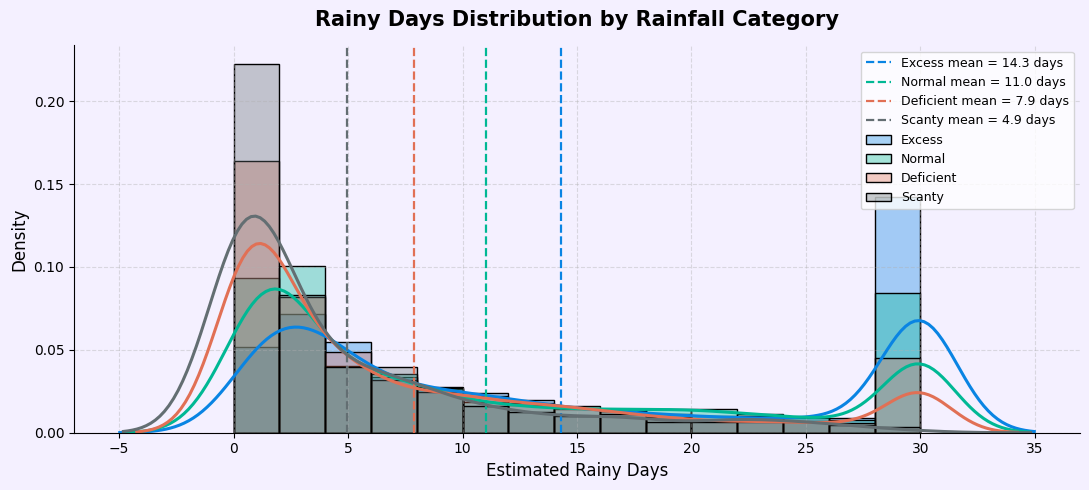

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
for cat, color in [('Excess','#0984e3'),('Normal','#00b894'),
                    ('Deficient','#e17055'),('Scanty','#636e72')]:
    sub = df[df['category']==cat]['rainy_days_est']
    sns.histplot(sub, bins=15, color=color, alpha=0.35, stat='density', ax=ax, label=cat)
    sns.kdeplot(sub, color=color, lw=2.2, ax=ax)
    ax.axvline(sub.mean(), color=color, lw=1.6, linestyle='--',
               label=f"{cat} mean = {sub.mean():.1f} days")

ax.set_title('Rainy Days Distribution by Rainfall Category', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Estimated Rainy Days', fontsize=12); ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=9)
ax.set_facecolor('#f4f0ff'); fig.patch.set_facecolor('#f4f0ff'); ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(CHARTS + '11_rainy_days_kde.png', dpi=150, bbox_inches='tight', facecolor='#f4f0ff')
plt.show()

---
## 12. Decade-wise Mean Rainfall — Grouped Bar Chart by Zone
Side-by-side bars per decade compare average monthly rainfall across agro-ecological zones. Annotated totals float above each bar. A shrinking bar in the Humid zone across decades reveals the long-term monsoon weakening signal most relevant to food security.

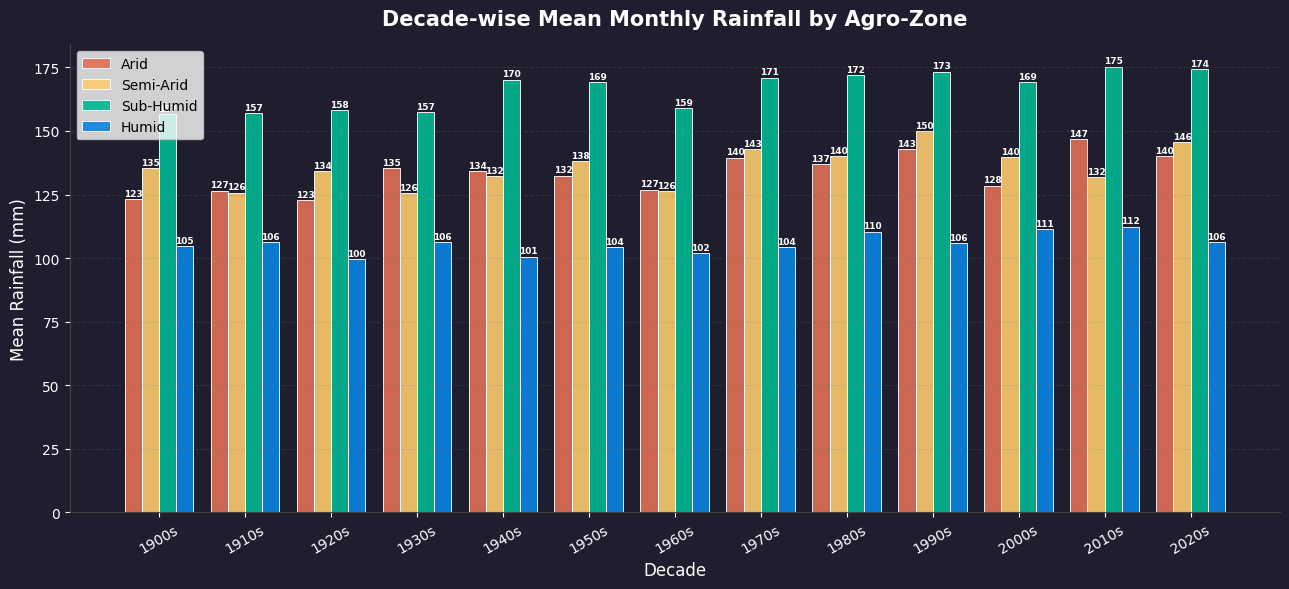

In [15]:
decade_zone = df.groupby(['decade_label','agro_zone'])['rainfall_mm'].mean().unstack(fill_value=0)
zone_palette = {'Arid':'#e17055','Semi-Arid':'#fdcb6e','Sub-Humid':'#00b894','Humid':'#0984e3'}

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(decade_zone)); w = 0.2; zones = ['Arid','Semi-Arid','Sub-Humid','Humid']
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]
for zone, off in zip(zones, offsets):
    vals = decade_zone.get(zone, pd.Series(0, index=decade_zone.index))
    bars = ax.bar(x + off, vals, width=w, color=zone_palette[zone],
                  label=zone, edgecolor='white', linewidth=0.7, alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{bar.get_height():.0f}", ha='center', va='bottom',
                fontsize=6.5, fontweight='bold', color='white')

ax.set_xticks(x); ax.set_xticklabels(decade_zone.index, fontsize=10, rotation=30)
ax.set_title('Decade-wise Mean Monthly Rainfall by Agro-Zone', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Decade', fontsize=12); ax.set_ylabel('Mean Rainfall (mm)', fontsize=12)
ax.legend(fontsize=10)
ax.set_facecolor('#1e1e2e'); fig.patch.set_facecolor('#1e1e2e')
ax.title.set_color('white'); ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white'); ax.tick_params(colors='white')
ax.grid(axis='y', linestyle='--', alpha=0.2, color='grey')
for spine in ax.spines.values(): spine.set_edgecolor('#444')
plt.tight_layout()
plt.savefig(CHARTS + '12_decade_zone_bar.png', dpi=150, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()

---
## 13. Departure % vs Rainy Days — Hexbin Density
Hexagonal bins show where the majority of district-months cluster in the departure-vs-rainy-days plane. The dense core near zero departure and moderate rainy days represents the climatological normal; rare hot cells in extremes are drought or flood outliers that stress infrastructure.

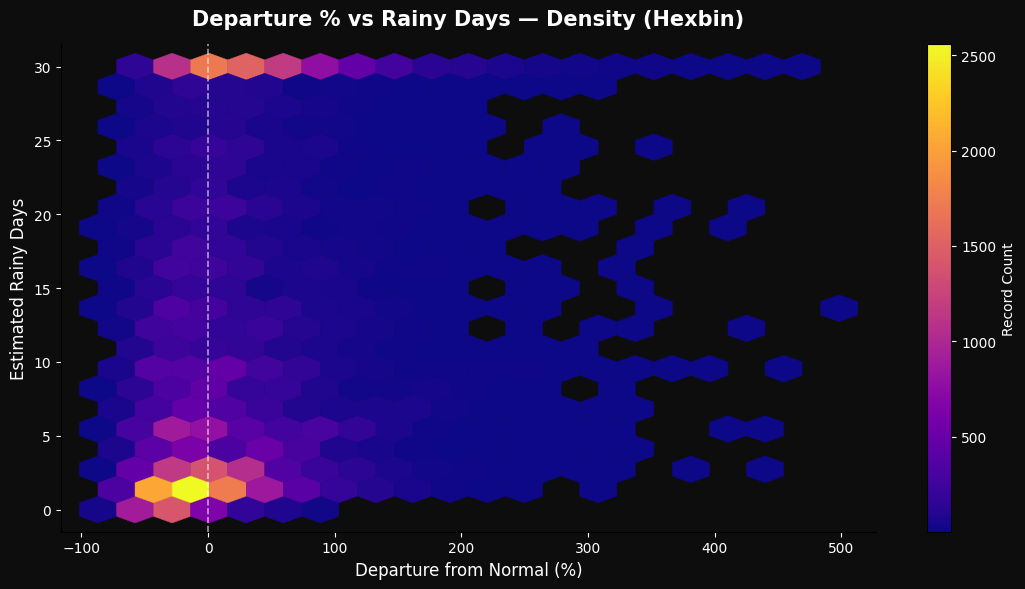

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
hb = ax.hexbin(df['departure_pct'], df['rainy_days_est'],
               gridsize=20, cmap='plasma', mincnt=1, linewidths=0.3)
cb = fig.colorbar(hb, ax=ax, label='Record Count')
cb.ax.tick_params(labelsize=10)
ax.axvline(0, color='white', lw=1.2, linestyle='--', alpha=0.6)
ax.set_title('Departure % vs Rainy Days — Density (Hexbin)', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Departure from Normal (%)', fontsize=12); ax.set_ylabel('Estimated Rainy Days', fontsize=12)
ax.set_facecolor('#0d0d0d'); fig.patch.set_facecolor('#0d0d0d')
ax.title.set_color('white'); ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white'); ax.tick_params(colors='white')
cb.set_label('Record Count', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
plt.tight_layout()
plt.savefig(CHARTS + '13_departure_rainydays_hexbin.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

---
## 14. Correlation Matrix — All Numerical Features
Lower-triangular heatmap across 5 key numeric variables. Red = strong positive, blue = strong negative. The near-perfect correlation between departure_mm and departure_pct confirms they carry the same signal — a critical insight for avoiding feature redundancy in predictive drought models.

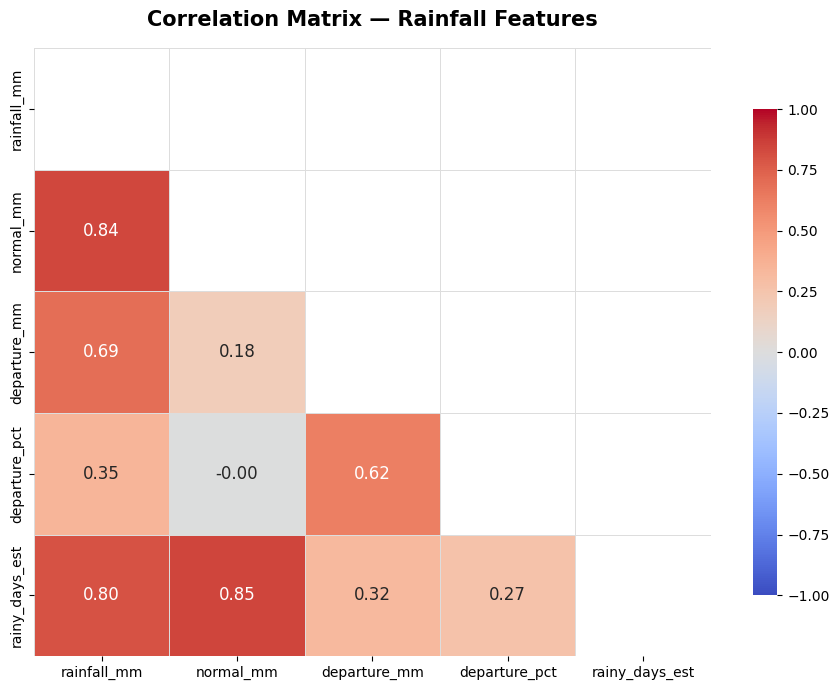

In [17]:
num_cols = ['rainfall_mm','normal_mm','departure_mm','departure_pct','rainy_days_est']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#ddd', ax=ax,
            cbar_kws={'shrink':0.8}, annot_kws={'fontsize':12})
ax.set_title('Correlation Matrix — Rainfall Features', fontsize=15, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig(CHARTS + '14_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 15. Pairplot — Key Rainfall Indicators
Every key variable plotted against every other in a 4×4 grid. Diagonal KDE curves show whether the four IMD categories form distinct distributions. Bivariate scatter panels expose nonlinear relationships — such as the threshold effect between normal_mm and departure_pct — that single correlation values would miss.

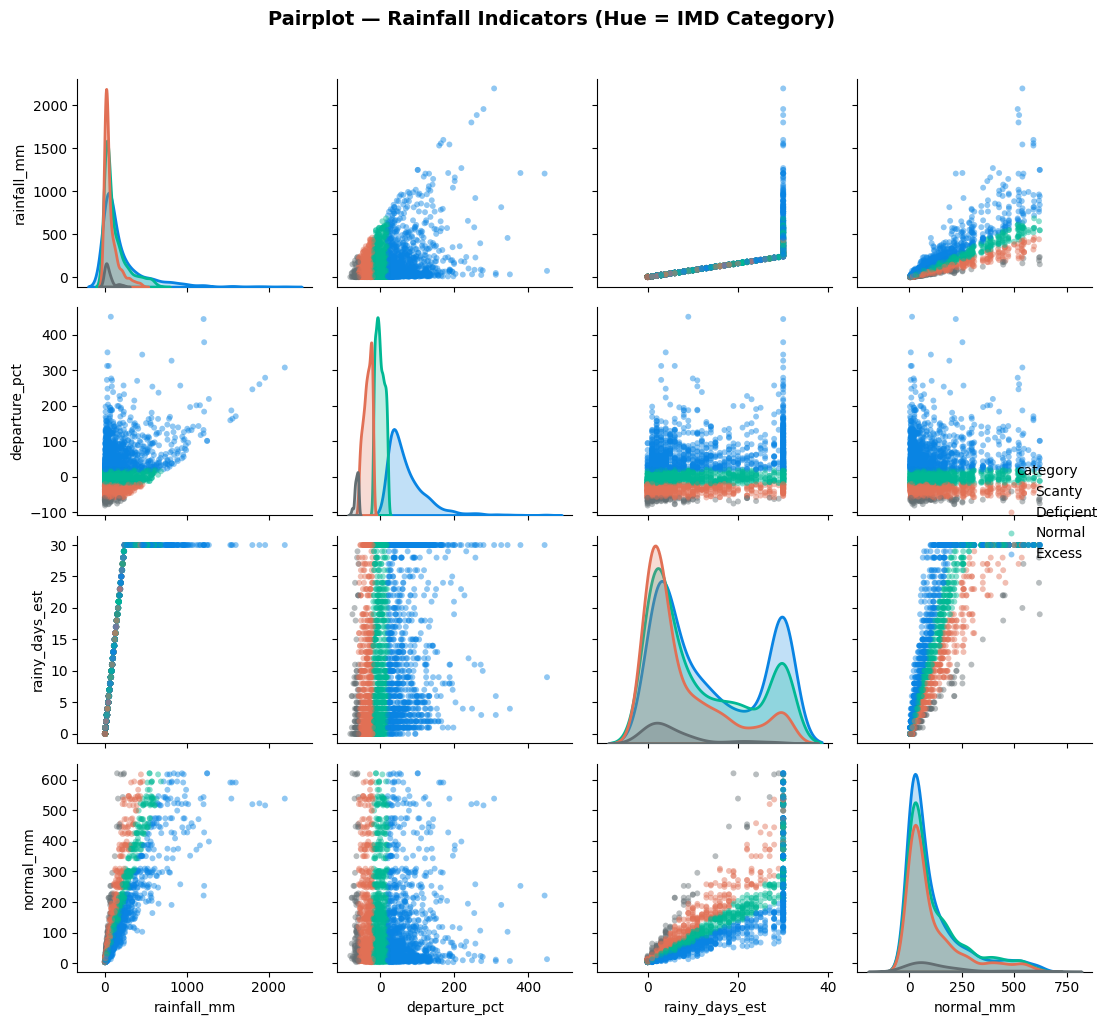

In [18]:
pair_cols = ['rainfall_mm','departure_pct','rainy_days_est','normal_mm']
cat_pal = {'Excess':'#0984e3','Normal':'#00b894','Deficient':'#e17055','Scanty':'#636e72'}

g = sns.pairplot(df[pair_cols + ['category']].sample(3000, random_state=42),
                 hue='category', palette=cat_pal,
                 hue_order=['Scanty','Deficient','Normal','Excess'],
                 diag_kind='kde',
                 plot_kws={'alpha':0.45,'edgecolor':'none','s':18},
                 diag_kws={'lw':2})
g.figure.suptitle('Pairplot — Rainfall Indicators (Hue = IMD Category)',
                   y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS + '15_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

---
## ✅ All 15 charts saved to `charts/`
Run the cell below to verify all files were created.

In [19]:
import os
files = sorted(os.listdir(CHARTS))
print(f"Total charts saved: {len(files)}")
for f in files:
    size_kb = os.path.getsize(CHARTS + f) // 1024
    print(f"  {f}  ({size_kb} KB)")

Total charts saved: 47
  01_category_distribution.png  (53 KB)
  01_category_donut.png  (78 KB)
  01_event_type_donut.png  (59 KB)
  02_annual_aqi_trend.png  (67 KB)
  02_yearly_frequency.png  (159 KB)
  02_yearly_trend.png  (91 KB)
  03_monthly_polar.png  (259 KB)
  04_aqi_violin.png  (363 KB)
  04_category_violin.png  (157 KB)
  04_temp_violin.png  (143 KB)
  04_wind_violin.png  (141 KB)
  05_deaths_anomaly_scatter.png  (243 KB)
  05_deaths_damage_scatter.png  (165 KB)
  05_departure_scatter.png  (634 KB)
  05_pm25_aqi_bubble.png  (324 KB)
  06_heatmap_year_month.png  (200 KB)
  06_year_month_heatmap.png  (119 KB)
  07_basin_category_stacked.png  (60 KB)
  07_top10_deadliest.png  (106 KB)
  07_top10_rainfall.png  (132 KB)
  07_top15_stations.png  (87 KB)
  08_state_category_stacked.png  (78 KB)
  08_state_events_stacked.png  (65 KB)
  08_state_stacked.png  (89 KB)
  08_top10_deadliest.png  (93 KB)
  09_agrozone_category_heatmap.png  (71 KB)
  09_category_pollutant_heatmap.png  (70 KB